In [1]:
import json
from freezeplots import (
    combined,
    complete,
    plot_supercooling,
)


from freezeplots.paths import PROC_DATA_DIR, PLOT_DIR, CHANNEL_LAYOUT_PATH
with CHANNEL_LAYOUT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    channel_layout = json.load(file)

input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "EJ04-05A1-2.png"

In [11]:
# ============================================================
# Dilution labels
# ============================================================

dilution_labels = [
    "2.5×10⁻¹",
    "2.5×10⁻²",
    "2.5×10⁻³",
    "2.5×10⁻⁴",
    "2.5×10⁻⁵",
    "2.5×10⁻⁶",
    "2.5×10⁻⁷",
    "2.5×10⁻⁸",
]


# ============================================================
# Colors
# ============================================================

# Darker colors represent higher concentrations.
# Lighter colors represent stronger dilutions.
#
# The same dilution receives the same color in all four groups.

TREATMENT_COLORS = {
    "2.5×10⁻": "#440154",  # dark purple
    "2.5×10⁻²": "#46327E",  # purple
    "2.5×10⁻³": "#365C8D",  # blue
    "2.5×10⁻⁴": "#277F8E",  # blue-teal
    "2.5×10⁻⁵": "#1FA187",  # teal-green
    "2.5×10⁻⁶": "#4AC16D",  # green
    "2.5×10⁻⁷": "#A0DA39",  # yellow-green
    "2.5×10⁻⁸": "#DCE319",  # bright yellow-green
}

In [12]:
def build_dilution_plots(
    experiment_ids,
    first_channel,
):
    """
    Create eight boxplot definitions for a dilution series.

    Parameters
    ----------
    experiment_ids
        Experiments whose corresponding channels are pooled.

    first_channel
        Number of the channel containing the first dilution.
        Use 1 for Weta and 9 for Grasshopper.
    """
    plots = []

    for offset, dilution_label in enumerate(
        dilution_labels
    ):
        channel = f"TC{first_channel + offset}"

        plots.append(
            combined(
                dilution_label,
                {
                    experiment_id: [channel]
                    for experiment_id in experiment_ids
                },
            )
        )

    return plots

In [13]:
plot_sections = [
    {
        "label": "Weta",
        "gap_after": 1.0,
        "plots": build_dilution_plots(
            experiment_ids=[
                "EJ04A1",
                "EJ04A2",
            ],
            first_channel=1,
        ),
    },

    {
        "label": "Weta 100 µl",
        "gap_after": 1.0,
        "plots": build_dilution_plots(
            experiment_ids=[
                "EJ05A1",
                "EJ05A2",
            ],
            first_channel=1,
        ),
    },

    {
        "label": "Grasshopper",
        "gap_after": 1.0,
        "plots": build_dilution_plots(
            experiment_ids=[
                "EJ04A1",
                "EJ04A2",
            ],
            first_channel=9,
        ),
    },

    {
        "label": "Grasshopper 100 µl",
        "gap_after": 1.0,
        "plots": build_dilution_plots(
            experiment_ids=[
                "EJ05A1",
                "EJ05A2",
            ],
            first_channel=9,
        ),
    },
]

Loaded 871 channel records from /home/juk/freeze/data/data_processed/manual_supercooling_events.csv
Plot saved to: /home/juk/freeze/output/plots/EJ04-05A1-2.png


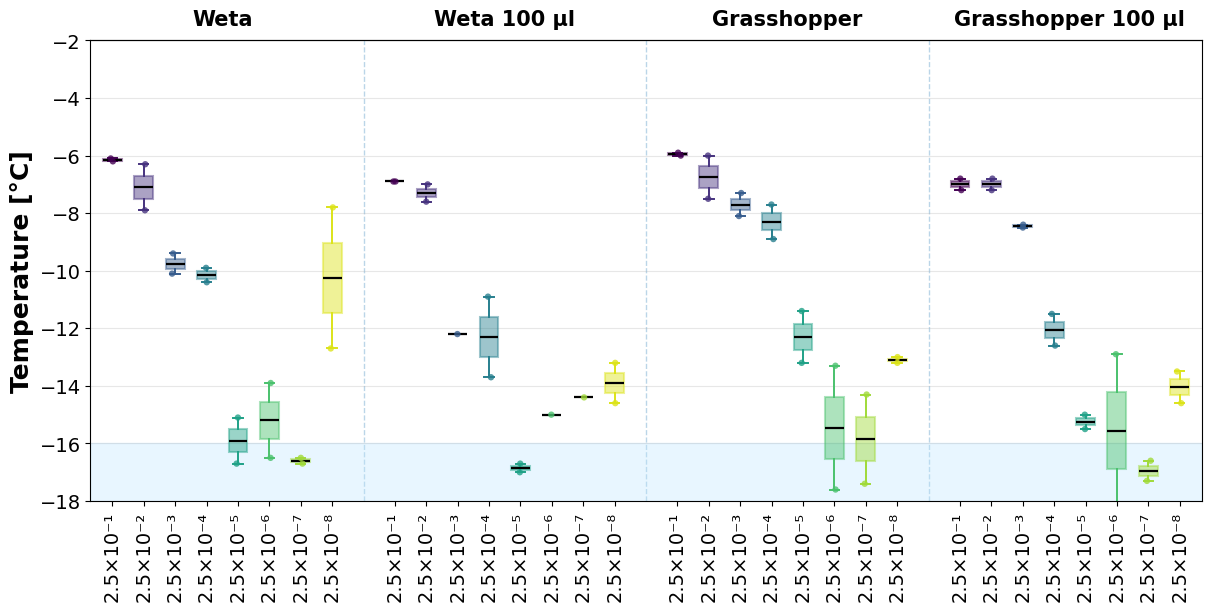

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Temperature [°C]'>)

In [14]:
plot_supercooling(
    plot_sections=plot_sections,
    treatment_colors=TREATMENT_COLORS,
    input_path=input_path,
    output_path=output_path,

    title=None,
    
    x_label_rotation=90,

    figsize = (12, 6),
    y_range=(-18, -2),
    tick_label_size=14,
    group_label_size=15,
    axis_label_size=18,

    show_legend=False,
)